In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("credit_card_fraud_10k.csv")

In [27]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [28]:
(df["amount"] == 0).any()

np.True_

In [29]:
# Returns an array/list of column names containing 0
df.columns[(df == 0).any()].tolist()


['amount',
 'transaction_hour',
 'foreign_transaction',
 'location_mismatch',
 'velocity_last_24h',
 'is_fraud']

In [30]:
(df["amount"] < 0).any()

np.False_

In [ ]:
#Lets start handle outliers



In [31]:
from sklearn.preprocessing import PowerTransformer

In [32]:

yj = PowerTransformer(method='yeo-johnson')

df["amount"] = yj.fit_transform(df[['amount']])



In [33]:
df["velocity_last_24h"] = yj.fit_transform(df[["velocity_last_24h"]])

In [34]:
df["velocity_last_24h"].skew()

np.float64(-0.03512050987890932)

<Axes: ylabel='Frequency'>

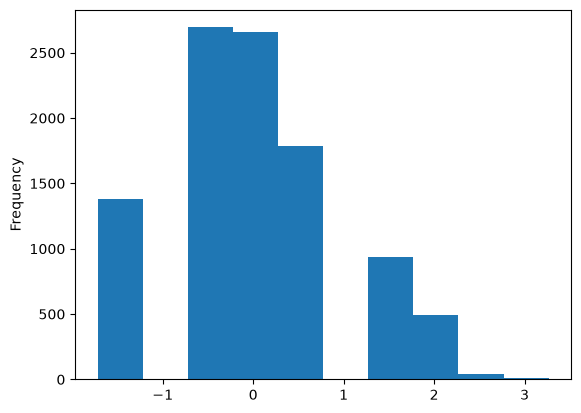

In [35]:
df["velocity_last_24h"].plot(kind='hist')

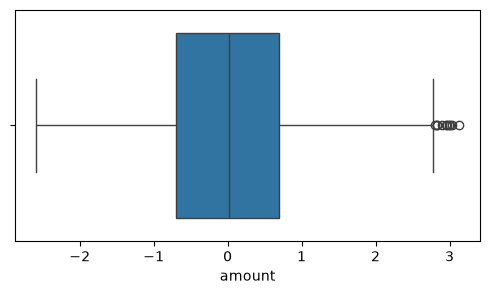

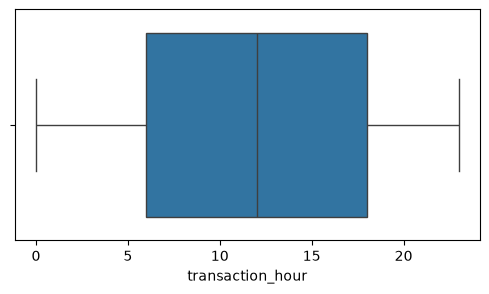

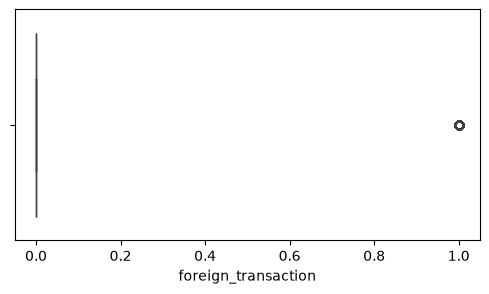

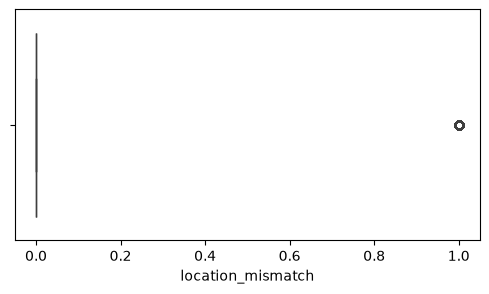

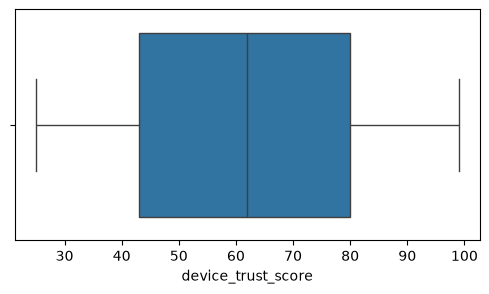

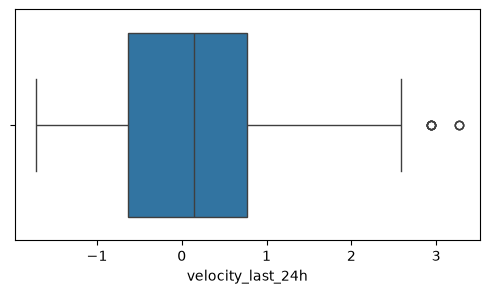

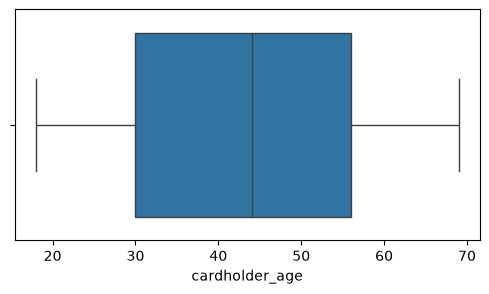

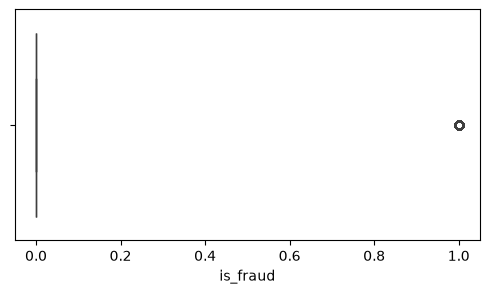

In [36]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,3))
        sns.boxplot(x=df[col])